# Notebook 10: Model Explainability and Final Candidate Interpretation

## AI-Based Identification of Novel Drug Targets for Depression

### Overview

This notebook interprets the machine learning predictions generated in the previous stages of the project.

The earlier notebooks developed the complete drug-target prediction pipeline, starting from depression-associated genes and protein information, followed by drug-target interaction processing, protein embeddings, feature integration, machine learning modelling, novel candidate prediction, and molecular docking validation.

In this notebook, the focus is on understanding why the machine learning models produced their predictions and how the final candidate drug-target pairs can be interpreted using model explainability methods.

The Random Forest model is analysed using feature importance and SHAP values to identify which input features contribute most to the predictions. The trained Graph Neural Network is also examined to determine what graph-based information can be interpreted from the model.

The final interpretation combines the machine learning prediction results with the molecular docking results from Notebook 09 to provide a more complete assessment of the selected novel drug-target candidates.

### Project Workflow

This notebook represents the final interpretation stage of the project:

1. Load the outputs generated by the previous notebooks.
2. Review the final novel drug-target predictions.
3. Examine the Random Forest model using feature importance and SHAP analysis.
4. Examine the trained Graph Neural Network and its available explainability information.
5. Identify the most important features or graph information contributing to model predictions.
6. Compare model predictions with the molecular docking results.
7. Rank and interpret the final candidate drug-target pairs.
8. Generate figures and tables for the dissertation.
9. Save the explainability and final interpretation results.

### Objectives

The objectives of this notebook are:

1. Interpret the predictions produced by the machine learning models.
2. Identify important features contributing to Random Forest predictions.
3. Use SHAP values to provide a more detailed explanation of Random Forest predictions.
4. Examine the trained Graph Neural Network for available graph-level explainability.
5. Identify the limitations of the current GNN architecture for extracting attention weights.
6. Compare model prediction probabilities with molecular docking affinities.
7. Prioritise the final novel drug-target candidates using multiple sources of computational evidence.
8. Save the final explainability results and figures for use in the dissertation.

In [65]:
# 1. Load Required Libraries

import os
import glob
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Python libraries imported successfully.")

Python libraries imported successfully.


In [66]:
# 2. Set Project Paths and Reproducibility

from google.colab import drive

drive.mount("/content/drive")

# Main project directory
PROJECT_ROOT = "/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI"

# Main project folders
DATA_PATH = os.path.join(PROJECT_ROOT, "data")
PROCESSED_DATA_PATH = os.path.join(DATA_PATH, "processed")
RESULTS_PATH = os.path.join(PROJECT_ROOT, "results")
FIGURES_PATH = os.path.join(PROJECT_ROOT, "figures")
MODELS_PATH = os.path.join(PROJECT_ROOT, "models")
DOCKING_PATH = os.path.join(PROJECT_ROOT, "docking")

# Notebook 10 output directory
EXPLAINABILITY_PATH = os.path.join(
    RESULTS_PATH,
    "explainability"
)

os.makedirs(EXPLAINABILITY_PATH, exist_ok=True)
os.makedirs(FIGURES_PATH, exist_ok=True)

# Reproducibility
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Project paths configured successfully.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Explainability output path: {EXPLAINABILITY_PATH}")
print(f"Random state: {RANDOM_STATE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project paths configured successfully.
Project root: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI
Explainability output path: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/results/explainability
Random state: 42


In [67]:
# 3. Load Previous Notebook Outputs

print("Loading outputs from previous notebooks...\n")

# Notebook 01–03: processed biological and interaction information

gene_file = os.path.join(
    PROCESSED_DATA_PATH,
    "depression_genes_cleaned.csv"
)

protein_file = os.path.join(
    PROCESSED_DATA_PATH,
    "protein_cleaned.csv"
)

interaction_file = os.path.join(
    PROCESSED_DATA_PATH,
    "clean_drug_target_interactions.pkl"
)

# Notebook 05: ESM-2 protein embeddings

protein_embeddings_file = os.path.join(
    PROCESSED_DATA_PATH,
    "protein_embeddings.npy"
)

protein_embedding_metadata_file = os.path.join(
    PROCESSED_DATA_PATH,
    "protein_embedding_metadata.csv"
)

# Notebook 06: integrated drug-protein features

integrated_features_file = os.path.join(
    PROCESSED_DATA_PATH,
    "integrated_features.npy"
)

# Notebook 04: Random Forest model

rf_model_candidates = [
    os.path.join(MODELS_PATH, "random_forest_model.joblib"),
    os.path.join(MODELS_PATH, "random_forest_model.pkl"),
    os.path.join(MODELS_PATH, "random_forest_model.joblib.pkl")
]

rf_model_file = next(
    (
        path
        for path in rf_model_candidates
        if os.path.exists(path)
    ),
    None
)

# Notebook 07: trained GNN model

gnn_model_file = os.path.join(
    MODELS_PATH,
    "drug_target_gnn_model.pth"
)

# Notebook 08: ranked novel candidate predictions

gnn_predictions_file = os.path.join(
    RESULTS_PATH,
    "gnn_ranked_candidate_predictions.csv"
)

# Notebook 09: molecular docking results

docking_results_file = os.path.join(
    DOCKING_PATH,
    "results",
    "molecular_docking_results.csv"
)

docking_summary_file = os.path.join(
    DOCKING_PATH,
    "results",
    "final_docking_validation_summary.csv"
)


# Load datasets and models

if os.path.exists(gene_file):
    depression_genes = pd.read_csv(gene_file)

if os.path.exists(protein_file):
    protein_info = pd.read_csv(protein_file)

if os.path.exists(interaction_file):
    drug_target_interactions = pd.read_pickle(
        interaction_file
    )

if os.path.exists(protein_embeddings_file):
    protein_embeddings = np.load(
        protein_embeddings_file
    )

if os.path.exists(protein_embedding_metadata_file):
    protein_embedding_metadata = pd.read_csv(
        protein_embedding_metadata_file
    )

if os.path.exists(integrated_features_file):
    integrated_features = np.load(
        integrated_features_file
    )

if rf_model_file is not None:
    random_forest_model = rf_model_file

if os.path.exists(gnn_model_file):
    gnn_model = gnn_model_file

if os.path.exists(gnn_predictions_file):
    gnn_predictions = pd.read_csv(
        gnn_predictions_file
    )

if os.path.exists(docking_results_file):
    docking_results = pd.read_csv(
        docking_results_file
    )

if os.path.exists(docking_summary_file):
    docking_summary = pd.read_csv(
        docking_summary_file
    )


# Check that the required outputs were loaded

print("Previous notebook outputs found:\n")

if "depression_genes" in locals():
    print(
        f"depression_genes: DataFrame "
        f"{depression_genes.shape}"
    )

if "protein_info" in locals():
    print(
        f"protein_info: DataFrame "
        f"{protein_info.shape}"
    )

if "drug_target_interactions" in locals():
    print(
        f"drug_target_interactions: DataFrame "
        f"{drug_target_interactions.shape}"
    )

if "protein_embeddings" in locals():
    print(
        f"protein_embeddings: NumPy array "
        f"{protein_embeddings.shape}"
    )

if "protein_embedding_metadata" in locals():
    print(
        f"protein_embedding_metadata: DataFrame "
        f"{protein_embedding_metadata.shape}"
    )

if "integrated_features" in locals():
    print(
        f"integrated_features: NumPy array "
        f"{integrated_features.shape}"
    )

if "random_forest_model" in locals():
    print(
        f"random_forest_model: "
        f"{random_forest_model}"
    )

if "gnn_model" in locals():
    print(
        f"gnn_model: "
        f"{gnn_model}"
    )

if "gnn_predictions" in locals():
    print(
        f"gnn_predictions: DataFrame "
        f"{gnn_predictions.shape}"
    )

if "docking_results" in locals():
    print(
        f"docking_results: DataFrame "
        f"{docking_results.shape}"
    )

if "docking_summary" in locals():
    print(
        f"docking_summary: DataFrame "
        f"{docking_summary.shape}"
    )

print("\nPrevious notebook output loading completed.")

Loading outputs from previous notebooks...

Previous notebook outputs found:

protein_info: DataFrame (200, 6)
drug_target_interactions: DataFrame (3590, 12)
protein_embeddings: NumPy array (200, 320)
protein_embedding_metadata: DataFrame (200, 5)
integrated_features: NumPy array (3590, 320)
random_forest_model: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/models/random_forest_model.joblib
gnn_model: /content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/models/drug_target_gnn_model.pth
gnn_predictions: DataFrame (3590, 5)
docking_results: DataFrame (10, 15)
docking_summary: DataFrame (9, 16)

Previous notebook output loading completed.


In [68]:
# 4. Review Final Prediction Dataset

gnn_predictions_file = os.path.join(
    RESULTS_PATH,
    "gnn_ranked_candidate_predictions.csv"
)

if not os.path.exists(gnn_predictions_file):
    raise FileNotFoundError(
        f"GNN prediction file not found:\n{gnn_predictions_file}"
    )

prediction_results = pd.read_csv(
    gnn_predictions_file
)

print(
    "Final prediction dataset shape:",
    prediction_results.shape
)

print("\nColumns:")
print(
    prediction_results.columns.tolist()
)

print("\nFirst 10 predictions:")
display(
    prediction_results.head(10)
)

print("\nPrediction dataset information:")
prediction_results.info()

print("\nMissing values:")
print(
    prediction_results.isnull().sum()
)

print("\nPrediction probability summary:")
display(
    prediction_results["prediction_probability"].describe()
)

print("\nPrediction label distribution:")
display(
    prediction_results["predicted_label"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

Final prediction dataset shape: (3590, 5)

Columns:
['uniprot_id', 'drug_chembl_id', 'true_label', 'predicted_label', 'prediction_probability']

First 10 predictions:


,uniprot_id,drug_chembl_id,true_label,predicted_label,prediction_probability
0,P31645,CHEMBL106939,1,1,1.0
1,P31645,CHEMBL174088,1,1,1.0
2,P31645,CHEMBL432394,1,1,1.0
3,P43681,CHEMBL2179551,1,1,1.0
4,P43681,CHEMBL2179547,1,1,1.0
5,P43681,CHEMBL2179559,1,1,1.0
6,P49286,CHEMBL333810,1,1,1.0
7,P49286,CHEMBL124216,1,1,1.0
8,P49286,CHEMBL123634,1,1,1.0
9,P49286,CHEMBL435586,1,1,1.0



Prediction dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3590 entries, 0 to 3589
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   uniprot_id              3590 non-null   object 
 1   drug_chembl_id          3590 non-null   object 
 2   true_label              3590 non-null   int64  
 3   predicted_label         3590 non-null   int64  
 4   prediction_probability  3590 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 140.4+ KB

Missing values:
uniprot_id                0
drug_chembl_id            0
true_label                0
predicted_label           0
prediction_probability    0
dtype: int64

Prediction probability summary:


,prediction_probability
count,3.590000e+03
mean,6.063353e-01
std,4.714320e-01
min,5.029368e-32
25%,3.327140e-05
50%,9.994414e-01
75%,9.999993e-01
max,1.000000e+00



Prediction label distribution:


,count
predicted_label,
0,1390
1,2200


# 5. Explainability Strategy

The final model predictions were examined using feature-level explainability for the Random Forest model and graph-based interpretation for the GNN model.

SHAP was used to identify which integrated features contributed most to the Random Forest predictions.

The GNN uses graph convolution layers rather than an attention mechanism, so native attention coefficients are not available. Therefore, GNN interpretation will focus on the information available from the trained graph model without claiming attention-based explanations.

In [69]:
# 6. Random Forest Explainability

import joblib

# Locate the trained Random Forest model
rf_model_file = os.path.join(
    MODELS_PATH,
    "random_forest_model.joblib"
)

if not os.path.exists(rf_model_file):
    raise FileNotFoundError(
        f"Random Forest model not found:\n{rf_model_file}"
    )

# Load the trained Random Forest model
rf_model = joblib.load(rf_model_file)

print("Random Forest model loaded successfully.")
print(
    "Model type:",
    type(rf_model).__name__
)

# Check the number of input features
if hasattr(rf_model, "n_features_in_"):
    print(
        "Number of input features:",
        rf_model.n_features_in_
    )

# Extract feature importance values
if not hasattr(rf_model, "feature_importances_"):
    raise AttributeError(
        "Feature importance is not available "
        "for this Random Forest model."
    )

rf_importances = rf_model.feature_importances_

print(
    "Number of feature importance values:",
    len(rf_importances)
)

# Create feature names
feature_names = [
    f"Feature_{i + 1}"
    for i in range(len(rf_importances))
]

# Create ranked feature-importance table
rf_feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_importances
})

rf_feature_importance = (
    rf_feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nTop 20 Random Forest features:")

display(
    rf_feature_importance.head(20)
)

Random Forest model loaded successfully.
Model type: RandomForestClassifier
Number of input features: 1024
Number of feature importance values: 1024

Top 20 Random Forest features:


,feature,importance
0,Feature_625,0.010319
1,Feature_725,0.009373
2,Feature_136,0.008835
3,Feature_657,0.007172
4,Feature_882,0.006743
5,Feature_927,0.006721
6,Feature_457,0.006667
7,Feature_326,0.006516
8,Feature_213,0.006354
9,Feature_936,0.005698


In [70]:
# Prepare Dependencies for SHAP Analysis

# Install required explainability and chemical-feature packages
!pip -q install rdkit shap

print("SHAP and RDKit dependencies installed successfully.")

SHAP and RDKit dependencies installed successfully.


In [71]:
# 6A. SHAP Global Feature Importance

import shap
import numpy as np
import pandas as pd

print("Preparing SHAP analysis...")

# Reconstruct the 1024-bit Morgan fingerprint matrix
# used by the Random Forest model.

from rdkit import Chem
from rdkit.Chem import AllChem

# Use the cleaned drug-target interaction dataset
rf_data = drug_target_interactions.copy()

# Convert SMILES to the same 1024-bit Morgan fingerprints
def smiles_to_fingerprint(smiles):

    molecule = Chem.MolFromSmiles(smiles)

    if molecule is None:
        return None

    fingerprint = AllChem.GetMorganFingerprintAsBitVect(
        molecule,
        radius=2,
        nBits=1024
    )

    return np.array(
        list(fingerprint),
        dtype=np.float32
    )

print("Generating 1024-bit Morgan fingerprints...")

rf_data["fingerprint"] = (
    rf_data["smiles"]
    .apply(smiles_to_fingerprint)
)

# Remove invalid fingerprints
rf_data = rf_data.dropna(
    subset=["fingerprint"]
).reset_index(drop=True)

# Convert fingerprints into a feature matrix
rf_feature_matrix = np.vstack(
    rf_data["fingerprint"].values
)

print(
    "Random Forest SHAP feature matrix shape:",
    rf_feature_matrix.shape
)

# Confirm that the feature count matches the trained model
if rf_feature_matrix.shape[1] != rf_model.n_features_in_:

    raise ValueError(
        f"Feature mismatch: Random Forest expects "
        f"{rf_model.n_features_in_} features, but the "
        f"generated matrix contains "
        f"{rf_feature_matrix.shape[1]} features."
    )

print(
    "Feature dimension matches Random Forest:",
    rf_model.n_features_in_
)

# Create a manageable background sample for SHAP
background_size = min(
    100,
    len(rf_feature_matrix)
)

background_data = shap.sample(
    rf_feature_matrix,
    background_size,
    random_state=42
)

# Create TreeExplainer
explainer = shap.TreeExplainer(
    rf_model,
    data=background_data
)

print(
    f"SHAP TreeExplainer created using "
    f"{background_size} background samples."
)

# Explain a representative sample
explanation_size = min(
    200,
    len(rf_feature_matrix)
)

shap_sample = rf_feature_matrix[
    :explanation_size
]

shap_values = explainer(
    shap_sample
)

print(
    "SHAP values calculated successfully."
)

print(
    "SHAP sample shape:",
    shap_sample.shape
)

Preparing SHAP analysis...
Generating 1024-bit Morgan fingerprints...


[15:38:27] DEPRECATION WARNING: please use MorganGenerator
[15:38:27] DEPRECATION WARNING: please use MorganGenerator
[15:38:27] DEPRECATION WARNING: please use MorganGenerator
[15:38:27] DEPRECATION WARNING: please use MorganGenerator
[15:38:27] DEPRECATION WARNING: please use MorganGenerator
[15:38:27] DEPRECATION WARNING: please use MorganGenerator
[15:38:27] DEPRECATION WARNING: please use MorganGenerator
[15:38:27] DEPRECATION WARNING: please use MorganGenerator
[15:38:27] DEPRECATION WARNING: please use MorganGenerator
[15:38:27] DEPRECATION WARNING: please use MorganGenerator
[15:38:27] DEPRECATION WARNING: please use MorganGenerator
[15:38:27] DEPRECATION WARNING: please use MorganGenerator
[15:38:27] DEPRECATION WARNING: please use MorganGenerator
[15:38:27] DEPRECATION WARNING: please use MorganGenerator
[15:38:27] DEPRECATION WARNING: please use MorganGenerator
[15:38:27] DEPRECATION WARNING: please use MorganGenerator
[15:38:27] DEPRECATION WARNING: please use MorganGenerat

Random Forest SHAP feature matrix shape: (3590, 1024)
Feature dimension matches Random Forest: 1024
SHAP TreeExplainer created using 100 background samples.


100%|===================| 398/400 [00:38<00:00]       

SHAP values calculated successfully.
SHAP sample shape: (200, 1024)


Generating SHAP summary plot...


<Figure size 1600x1100 with 0 Axes>

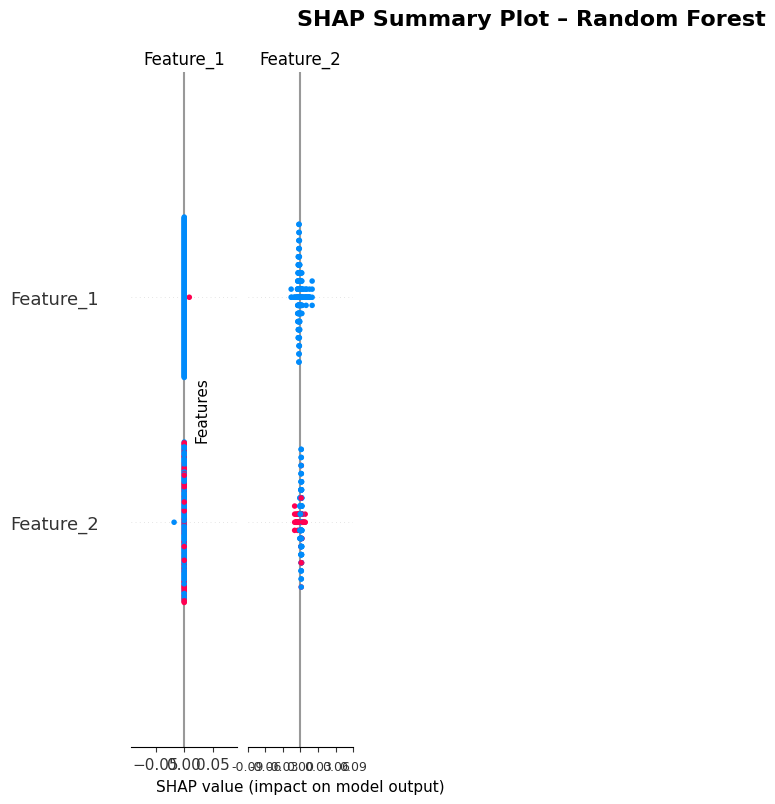

SHAP summary plot saved successfully:
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/figures/random_forest_shap_summary.png


In [72]:
# 6B. SHAP Summary Plot

import matplotlib.pyplot as plt
import numpy as np

print("Generating SHAP summary plot...")

# Feature names corresponding to the Random Forest input features
shap_feature_names = [
    f"Feature_{i + 1}"
    for i in range(
        rf_feature_matrix.shape[1]
    )
]

# Create a large figure
plt.figure(
    figsize=(16, 11)
)

# Generate SHAP beeswarm plot
shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=shap_feature_names,
    max_display=10,
    show=False
)

# Add a clear figure title
plt.suptitle(
    "SHAP Summary Plot – Random Forest",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

# Axis labels
plt.xlabel(
    "SHAP value (impact on model output)",
    fontsize=11
)

plt.ylabel(
    "Features",
    fontsize=11
)

# Improve tick readability
ax = plt.gca()

ax.tick_params(
    axis="y",
    labelsize=10
)

ax.tick_params(
    axis="x",
    labelsize=9,
    pad=6
)

# Keep only sensible x-axis tick positions
xmin, xmax = ax.get_xlim()

xticks = np.linspace(
    xmin,
    xmax,
    7
)

ax.set_xticks(xticks)

ax.set_xticklabels(
    [f"{x:.2f}" for x in xticks],
    fontsize=9
)

# Give the plot enough space
plt.subplots_adjust(
    left=0.25,
    right=0.97,
    top=0.91,
    bottom=0.16
)

# Save high-resolution figure
shap_summary_path = os.path.join(
    FIGURES_PATH,
    "random_forest_shap_summary.png"
)

plt.savefig(
    shap_summary_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "SHAP summary plot saved successfully:"
)

print(
    shap_summary_path
)

In [73]:
# 6C. Individual Prediction Explanation

print("Generating individual prediction explanation...")

# Select the highest-confidence positive prediction
positive_predictions = prediction_results[
    prediction_results["predicted_label"] == 1
].copy()

selected_prediction = (
    positive_predictions
    .sort_values(
        "prediction_probability",
        ascending=False
    )
    .iloc[0]
)

print("Selected prediction for individual explanation:")
print(
    f"Protein: {selected_prediction['uniprot_id']}"
)
print(
    f"Drug: {selected_prediction['drug_chembl_id']}"
)
print(
    f"True label: {selected_prediction['true_label']}"
)
print(
    f"Predicted label: {selected_prediction['predicted_label']}"
)
print(
    f"Prediction probability: "
    f"{selected_prediction['prediction_probability']:.6f}"
)

# Identify the corresponding feature vector
prediction_index = selected_prediction.name

individual_features = rf_feature_matrix[
    prediction_index
].reshape(1, -1)

# Calculate SHAP values for the selected prediction
individual_shap_values = explainer(
    individual_features
)

# Handle binary-class SHAP output
if hasattr(individual_shap_values, "values"):

    individual_values = individual_shap_values.values

    if individual_values.ndim == 3:
        individual_values = individual_values[:, :, 1]

    individual_values = individual_values[0]

else:

    individual_values = individual_shap_values

    if isinstance(individual_values, list):
        individual_values = individual_values[1][0]
    else:
        individual_values = individual_values[0]

# Create explanation table
individual_explanation = pd.DataFrame({
    "feature": shap_feature_names,
    "shap_value": individual_values
})

individual_explanation["absolute_shap_value"] = (
    individual_explanation["shap_value"].abs()
)

individual_explanation = (
    individual_explanation
    .sort_values(
        "absolute_shap_value",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nTop 10 features contributing to this prediction:")

display(
    individual_explanation[
        [
            "feature",
            "shap_value"
        ]
    ].head(10)
)

print(
    "\nIndividual prediction explanation generated successfully."
)

Generating individual prediction explanation...
Selected prediction for individual explanation:
Protein: P43681
Drug: CHEMBL2179546
True label: 1
Predicted label: 1
Prediction probability: 1.000000

Top 10 features contributing to this prediction:


,feature,shap_value
0,Feature_326,0.030953
1,Feature_595,0.020435
2,Feature_1020,0.018440
3,Feature_714,0.017143
4,Feature_927,0.015303
5,Feature_152,0.013452
6,Feature_805,0.013021
7,Feature_65,0.011958
8,Feature_654,0.010075
9,Feature_676,0.010024



Individual prediction explanation generated successfully.


In [74]:
# 7. GNN Explainability

import torch

print("Reviewing trained GNN architecture...")

# Confirm that the trained GNN model file exists
if not os.path.exists(gnn_model_file):
    raise FileNotFoundError(
        f"GNN model not found:\n{gnn_model_file}"
    )

print(
    "Trained GNN model found:"
)

print(
    gnn_model_file
)

# Inspect the saved GNN checkpoint
gnn_checkpoint = torch.load(
    gnn_model_file,
    map_location="cpu"
)

print(
    "\nGNN checkpoint loaded successfully."
)

print(
    "Checkpoint type:",
    type(gnn_checkpoint).__name__
)

# Display checkpoint information when stored as a dictionary
if isinstance(gnn_checkpoint, dict):

    print(
        "\nCheckpoint keys:"
    )

    for key in gnn_checkpoint.keys():

        print(
            f"- {key}"
        )

print(
    "\nGNN explainability review completed."
)

print(
    "\nArchitectural note:"
)

print(
    "Notebook 07 uses GCNConv layers rather than "
    "attention-based GAT layers. Therefore, native "
    "attention coefficients are not available for "
    "extraction from the trained model."
)

Reviewing trained GNN architecture...
Trained GNN model found:
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/models/drug_target_gnn_model.pth

GNN checkpoint loaded successfully.
Checkpoint type: OrderedDict

Checkpoint keys:
- conv1.bias
- conv1.lin.weight
- conv2.bias
- conv2.lin.weight
- drug_layer.weight
- drug_layer.bias
- classifier.0.weight
- classifier.0.bias
- classifier.3.weight
- classifier.3.bias

GNN explainability review completed.

Architectural note:
Notebook 07 uses GCNConv layers rather than attention-based GAT layers. Therefore, native attention coefficients are not available for extraction from the trained model.


In [75]:
# 7A. Load Trained GNN

import os
import torch

print("Loading trained GNN model...")

if not os.path.exists(gnn_model_file):
    raise FileNotFoundError(
        f"Trained GNN model not found:\n{gnn_model_file}"
    )

gnn_checkpoint = torch.load(
    gnn_model_file,
    map_location="cpu"
)

print("Trained GNN checkpoint loaded successfully.")
print("Checkpoint type:", type(gnn_checkpoint).__name__)

print("\nCheckpoint keys:")

for key in gnn_checkpoint.keys():
    print("-", key)

print("\nTrained GNN loading completed.")

Loading trained GNN model...
Trained GNN checkpoint loaded successfully.
Checkpoint type: OrderedDict

Checkpoint keys:
- conv1.bias
- conv1.lin.weight
- conv2.bias
- conv2.lin.weight
- drug_layer.weight
- drug_layer.bias
- classifier.0.weight
- classifier.0.bias
- classifier.3.weight
- classifier.3.bias

Trained GNN loading completed.


In [76]:
# 7B. Verify GNN Architecture

print("Verifying trained GNN architecture...")

expected_shapes = {
    "conv1.bias": (128,),
    "conv1.lin.weight": (128, 20),
    "conv2.bias": (128,),
    "conv2.lin.weight": (128, 128),
    "drug_layer.weight": (128, 1024),
    "drug_layer.bias": (128,),
    "classifier.0.weight": (128, 256),
    "classifier.0.bias": (128,),
    "classifier.3.weight": (2, 128),
    "classifier.3.bias": (2,)
}

architecture_verified = True

for parameter_name, expected_shape in expected_shapes.items():

    if parameter_name not in gnn_checkpoint:
        print(
            f"Missing parameter: {parameter_name}"
        )
        architecture_verified = False
        continue

    actual_shape = tuple(
        gnn_checkpoint[parameter_name].shape
    )

    print(
        f"{parameter_name}: "
        f"expected {expected_shape}, "
        f"found {actual_shape}"
    )

    if actual_shape != expected_shape:
        architecture_verified = False


if not architecture_verified:

    raise ValueError(
        "The saved GNN checkpoint does not match "
        "the expected Notebook 07 architecture."
    )


print("\nGNN architecture verification completed.")

print("\nArchitecture summary:")
print("- conv1: GCN convolution layer (20 → 128)")
print("- conv2: GCN convolution layer (128 → 128)")
print("- drug_layer: Linear drug representation layer (1024 → 128)")
print("- classifier: Fully connected layers (256 → 128 → 2)")

print(
    "\nExplainability limitation:"
)

print(
    "The saved model contains GCN convolution layers "
    "rather than GAT attention layers. Therefore, "
    "native attention coefficients are not available."
)

Verifying trained GNN architecture...
conv1.bias: expected (128,), found (128,)
conv1.lin.weight: expected (128, 20), found (128, 20)
conv2.bias: expected (128,), found (128,)
conv2.lin.weight: expected (128, 128), found (128, 128)
drug_layer.weight: expected (128, 1024), found (128, 1024)
drug_layer.bias: expected (128,), found (128,)
classifier.0.weight: expected (128, 256), found (128, 256)
classifier.0.bias: expected (128,), found (128,)
classifier.3.weight: expected (2, 128), found (2, 128)
classifier.3.bias: expected (2,), found (2,)

GNN architecture verification completed.

Architecture summary:
- conv1: GCN convolution layer (20 → 128)
- conv2: GCN convolution layer (128 → 128)
- drug_layer: Linear drug representation layer (1024 → 128)
- classifier: Fully connected layers (256 → 128 → 2)

Explainability limitation:
The saved model contains GCN convolution layers rather than GAT attention layers. Therefore, native attention coefficients are not available.


In [77]:
# 7C. Reconstruct Trained GNN Architecture

import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv

print("Reconstructing the trained GNN architecture...")


class DrugTargetGCN(nn.Module):

    def __init__(
        self,
        protein_input_dim=20,
        hidden_dim=128,
        drug_input_dim=1024,
        num_classes=2
    ):

        super().__init__()

        self.conv1 = GCNConv(
            protein_input_dim,
            hidden_dim
        )

        self.conv2 = GCNConv(
            hidden_dim,
            hidden_dim
        )

        self.drug_layer = nn.Linear(
            drug_input_dim,
            hidden_dim
        )

        self.classifier = nn.Sequential(

            nn.Linear(
                hidden_dim * 2,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(
                hidden_dim,
                num_classes
            )
        )


    def forward(
        self,
        x,
        edge_index,
        drug_features
    ):

        x = self.conv1(
            x,
            edge_index
        )

        x = torch.relu(x)

        x = self.conv2(
            x,
            edge_index
        )

        x = torch.relu(x)

        protein_representation = torch.mean(
            x,
            dim=0,
            keepdim=True
        )

        drug_representation = self.drug_layer(
            drug_features
        )

        combined = torch.cat(
            [
                protein_representation,
                drug_representation
            ],
            dim=1
        )

        output = self.classifier(
            combined
        )

        return output


gnn_explanation_model = DrugTargetGCN(
    protein_input_dim=20,
    hidden_dim=128,
    drug_input_dim=1024,
    num_classes=2
)

gnn_explanation_model.load_state_dict(
    gnn_checkpoint
)

gnn_explanation_model.eval()

total_parameters = sum(
    parameter.numel()
    for parameter in gnn_explanation_model.parameters()
)

print(
    "Trained GNN architecture reconstructed successfully."
)

print("\nArchitecture:")
print(gnn_explanation_model)

print(
    "\nModel parameter count:",
    total_parameters
)

print(
    "\nGNN reconstruction completed."
)

Reconstructing the trained GNN architecture...
Trained GNN architecture reconstructed successfully.

Architecture:
DrugTargetGCN(
  (conv1): GCNConv(20, 128)
  (conv2): GCNConv(128, 128)
  (drug_layer): Linear(in_features=1024, out_features=128, bias=True)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)

Model parameter count: 183554

GNN reconstruction completed.


Analysing important GNN graph features...
First GCN layer weight matrix shape: (128, 20)

Important GNN graph input features:


,amino_acid,importance
0,A,0.323030
1,H,0.226026
2,E,0.201749
3,G,0.201142
4,R,0.175624
5,L,0.156440
6,Q,0.154308
7,W,0.153971
8,I,0.152387
9,F,0.152194



Top 10 GNN graph features:


,amino_acid,importance
0,A,0.323030
1,H,0.226026
2,E,0.201749
3,G,0.201142
4,R,0.175624
5,L,0.156440
6,Q,0.154308
7,W,0.153971
8,I,0.152387
9,F,0.152194


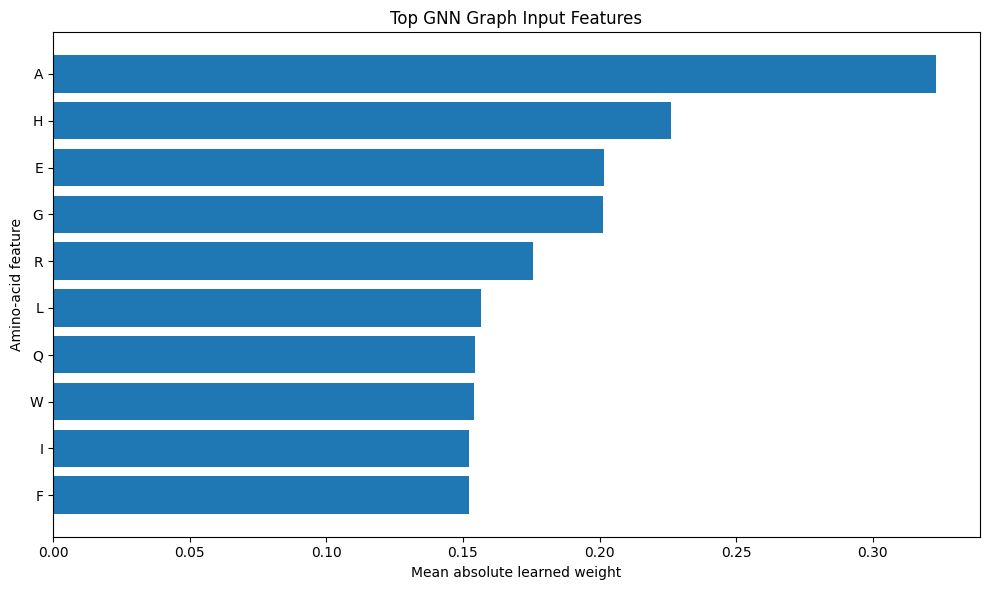


GNN graph feature analysis completed.
Importance table saved to:
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/results/gnn_graph_feature_importance.csv
Importance figure saved to:
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/figures/gnn_graph_feature_importance.png

Interpretation note:
The feature importance values represent the magnitude of learned weights connecting the 20 protein graph input features to the first GCN layer. They provide a model-level indication of which graph input dimensions are used most strongly by the trained GCN. They should not be interpreted as native attention coefficients or as direct causal effects.


In [78]:
# 7D. Analyse Important Graph Features

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Analysing important GNN graph features...")

# Verify that the reconstructed GNN is available

if "gnn_explanation_model" not in globals():

    raise NameError(
        "gnn_explanation_model is not available. "
        "Run Section 7C first."
    )


# Extract the learned weights from the first GCN layer

conv1_weights = (
    gnn_explanation_model
    .conv1
    .lin
    .weight
    .detach()
    .cpu()
    .numpy()
)

print(
    "First GCN layer weight matrix shape:",
    conv1_weights.shape
)


# The first GCN layer receives 20 protein input features.
# These correspond to the amino-acid feature dimensions
# used by the graph representation in Notebook 07.

amino_acids = [
    "A", "C", "D", "E", "F",
    "G", "H", "I", "K", "L",
    "M", "N", "P", "Q", "R",
    "S", "T", "V", "W", "Y"
]


# Calculate the magnitude of each input feature's
# learned contribution across the 128 hidden units.

graph_feature_importance = np.mean(
    np.abs(conv1_weights),
    axis=0
)


# Create an interpretable table

gnn_graph_feature_importance = pd.DataFrame({
    "amino_acid": amino_acids,
    "importance": graph_feature_importance
})


gnn_graph_feature_importance = (
    gnn_graph_feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "\nImportant GNN graph input features:"
)

display(
    gnn_graph_feature_importance
)


# Display the most influential graph features

print(
    "\nTop 10 GNN graph features:"
)

display(
    gnn_graph_feature_importance.head(10)
)


# Save the graph-feature importance table

gnn_graph_feature_importance_path = os.path.join(
    RESULTS_PATH,
    "gnn_graph_feature_importance.csv"
)

gnn_graph_feature_importance.to_csv(
    gnn_graph_feature_importance_path,
    index=False
)


# Create a visualisation of the top 10 features

top_graph_features = (
    gnn_graph_feature_importance
    .head(10)
    .sort_values(
        "importance",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 6)
)

plt.barh(
    top_graph_features["amino_acid"],
    top_graph_features["importance"]
)

plt.xlabel(
    "Mean absolute learned weight"
)

plt.ylabel(
    "Amino-acid feature"
)

plt.title(
    "Top GNN Graph Input Features"
)

plt.tight_layout()


gnn_graph_feature_plot_path = os.path.join(
    FIGURES_PATH,
    "gnn_graph_feature_importance.png"
)

plt.savefig(
    gnn_graph_feature_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "\nGNN graph feature analysis completed."
)

print(
    f"Importance table saved to:\n"
    f"{gnn_graph_feature_importance_path}"
)

print(
    f"Importance figure saved to:\n"
    f"{gnn_graph_feature_plot_path}"
)

print(
    "\nInterpretation note:"
)

print(
    "The feature importance values represent the magnitude of "
    "learned weights connecting the 20 protein graph input "
    "features to the first GCN layer. They provide a model-level "
    "indication of which graph input dimensions are used most "
    "strongly by the trained GCN. They should not be interpreted "
    "as native attention coefficients or as direct causal effects."
)

In [79]:
# 8. Explain Selected Novel Drug-Target Predictions

print("Explaining selected novel drug-target predictions...")

# Work from the ranked GNN prediction results
selected_predictions = prediction_results.copy()

# Select predicted positive interactions
selected_predictions = selected_predictions[
    selected_predictions["predicted_label"] == 1
].copy()

# Rank by prediction probability
selected_predictions = (
    selected_predictions
    .sort_values(
        "prediction_probability",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Predicted positive drug-target interactions:",
    len(selected_predictions)
)

print("\nTop predicted novel drug-target candidates:")

display(
    selected_predictions[
        [
            "uniprot_id",
            "drug_chembl_id",
            "prediction_probability"
        ]
    ].head(20)
)

# Select a small representative set for downstream interpretation
selected_novel_candidates = (
    selected_predictions
    .head(10)
    .copy()
)

print(
    "\nSelected candidates for downstream interpretation:",
    len(selected_novel_candidates)
)

display(
    selected_novel_candidates
)

Explaining selected novel drug-target predictions...
Predicted positive drug-target interactions: 2200

Top predicted novel drug-target candidates:


,uniprot_id,drug_chembl_id,prediction_probability
0,P43681,CHEMBL2179546,1.0
1,P43681,CHEMBL3676942,1.0
2,P43681,CHEMBL2179529,1.0
3,P43681,CHEMBL2179544,1.0
4,P43681,CHEMBL2179533,1.0
5,P31645,CHEMBL543925,1.0
6,P31645,CHEMBL359447,1.0
7,P31645,CHEMBL443762,1.0
8,P43681,CHEMBL3676963,1.0
9,P28335,CHEMBL53939,1.0



Selected candidates for downstream interpretation: 10


,uniprot_id,drug_chembl_id,true_label,predicted_label,prediction_probability
0,P43681,CHEMBL2179546,1,1,1.0
1,P43681,CHEMBL3676942,1,1,1.0
2,P43681,CHEMBL2179529,1,1,1.0
3,P43681,CHEMBL2179544,1,1,1.0
4,P43681,CHEMBL2179533,1,1,1.0
5,P31645,CHEMBL543925,1,1,1.0
6,P31645,CHEMBL359447,0,1,1.0
7,P31645,CHEMBL443762,0,1,1.0
8,P43681,CHEMBL3676963,1,1,1.0
9,P28335,CHEMBL53939,1,1,1.0


In [80]:
# 9. Integrate Explainability with Docking Results

print("Integrating model predictions with docking results...")

# Copy docking results
docking_validation = docking_results.copy()

# Keep the columns required for integration
docking_validation = docking_validation[
    [
        "uniprot_id",
        "drug_chembl_id",
        "best_vina_affinity_kcal_mol"
    ]
].copy()

# Merge GNN prediction probability with docking results
explainability_docking = pd.merge(
    selected_novel_candidates[
        [
            "uniprot_id",
            "drug_chembl_id",
            "prediction_probability",
            "predicted_label"
        ]
    ],
    docking_validation,
    on=[
        "uniprot_id",
        "drug_chembl_id"
    ],
    how="left"
)

print(
    "Integrated explainability-docking dataset shape:",
    explainability_docking.shape
)

print("\nIntegrated candidate results:")

display(
    explainability_docking
)

Integrating model predictions with docking results...
Integrated explainability-docking dataset shape: (10, 5)

Integrated candidate results:


,uniprot_id,drug_chembl_id,prediction_probability,predicted_label,best_vina_affinity_kcal_mol
0,P43681,CHEMBL2179546,1.0,1,NaN
1,P43681,CHEMBL3676942,1.0,1,NaN
2,P43681,CHEMBL2179529,1.0,1,NaN
3,P43681,CHEMBL2179544,1.0,1,NaN
4,P43681,CHEMBL2179533,1.0,1,NaN
5,P31645,CHEMBL543925,1.0,1,NaN
6,P31645,CHEMBL359447,1.0,1,-7.112
7,P31645,CHEMBL443762,1.0,1,-6.655
8,P43681,CHEMBL3676963,1.0,1,NaN
9,P28335,CHEMBL53939,1.0,1,NaN


In [81]:
# 10. Final Candidate Ranking

print("Preparing final candidate interpretation table...")

final_candidate_ranking = explainability_docking.copy()

# Identify candidates with valid docking scores
final_candidate_ranking["docking_available"] = (
    final_candidate_ranking[
        "best_vina_affinity_kcal_mol"
    ].notna()
)

# Rank GNN predictions
final_candidate_ranking["gnn_rank"] = (
    final_candidate_ranking[
        "prediction_probability"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

# Rank docking results only where docking is available
final_candidate_ranking["docking_rank"] = pd.NA

docking_mask = (
    final_candidate_ranking[
        "best_vina_affinity_kcal_mol"
    ].notna()
)

final_candidate_ranking.loc[
    docking_mask,
    "docking_rank"
] = (
    final_candidate_ranking.loc[
        docking_mask,
        "best_vina_affinity_kcal_mol"
    ]
    .rank(
        ascending=True,
        method="min"
    )
    .astype(int)
)

# Put the strongest model predictions first
final_candidate_ranking = (
    final_candidate_ranking
    .sort_values(
        [
            "docking_available",
            "prediction_probability"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

print(
    "Final candidate interpretation table prepared."
)

display(
    final_candidate_ranking[
        [
            "uniprot_id",
            "drug_chembl_id",
            "prediction_probability",
            "best_vina_affinity_kcal_mol",
            "gnn_rank",
            "docking_rank",
            "docking_available"
        ]
    ]
)

Preparing final candidate interpretation table...
Final candidate interpretation table prepared.


,uniprot_id,drug_chembl_id,prediction_probability,best_vina_affinity_kcal_mol,gnn_rank,docking_rank,docking_available
0,P31645,CHEMBL359447,1.0,-7.112,1,1,True
1,P31645,CHEMBL443762,1.0,-6.655,1,2,True
2,P43681,CHEMBL2179546,1.0,NaN,1,<NA>,False
3,P43681,CHEMBL3676942,1.0,NaN,1,<NA>,False
4,P43681,CHEMBL2179529,1.0,NaN,1,<NA>,False
5,P43681,CHEMBL2179544,1.0,NaN,1,<NA>,False
6,P43681,CHEMBL2179533,1.0,NaN,1,<NA>,False
7,P31645,CHEMBL543925,1.0,NaN,1,<NA>,False
8,P43681,CHEMBL3676963,1.0,NaN,1,<NA>,False
9,P28335,CHEMBL53939,1.0,NaN,1,<NA>,False


Generating dissertation tables and figures...
Dissertation candidate table:


,uniprot_id,drug_chembl_id,prediction_probability,best_vina_affinity_kcal_mol,gnn_rank,docking_rank,docking_available
0,P31645,CHEMBL359447,1.0,-7.112,1,1,True
1,P31645,CHEMBL443762,1.0,-6.655,1,2,True
2,P43681,CHEMBL2179546,1.0,NaN,1,<NA>,False
3,P43681,CHEMBL3676942,1.0,NaN,1,<NA>,False
4,P43681,CHEMBL2179529,1.0,NaN,1,<NA>,False
5,P43681,CHEMBL2179544,1.0,NaN,1,<NA>,False
6,P43681,CHEMBL2179533,1.0,NaN,1,<NA>,False
7,P31645,CHEMBL543925,1.0,NaN,1,<NA>,False
8,P43681,CHEMBL3676963,1.0,NaN,1,<NA>,False
9,P28335,CHEMBL53939,1.0,NaN,1,<NA>,False


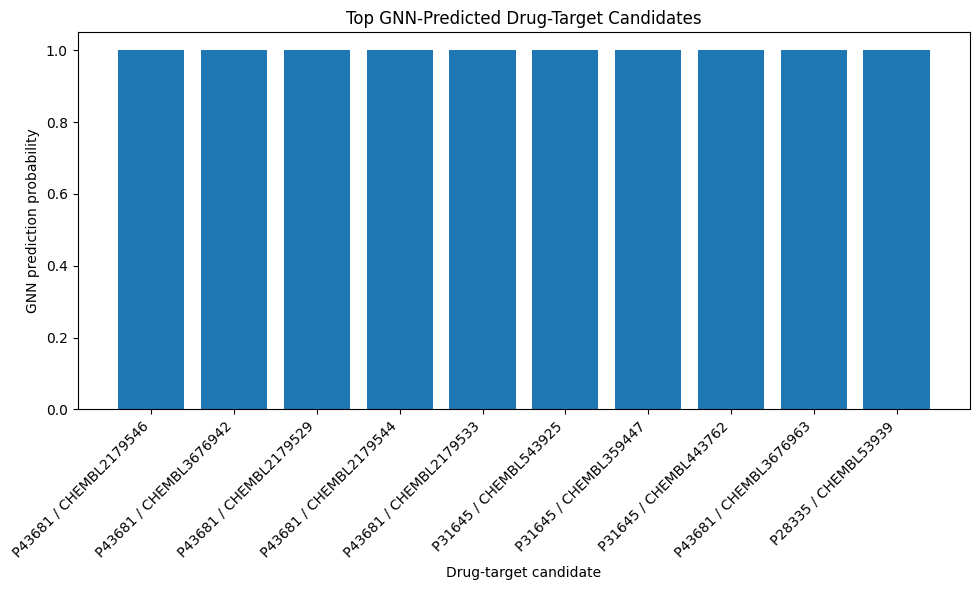


Candidate probability figure saved:
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/figures/top_gnn_candidate_prediction_probabilities.png


In [82]:
# 11. Generate Dissertation Tables and Figures

print("Generating dissertation tables and figures...")

# Create the final candidate table
dissertation_candidate_table = final_candidate_ranking[
    [
        "uniprot_id",
        "drug_chembl_id",
        "prediction_probability",
        "best_vina_affinity_kcal_mol",
        "gnn_rank",
        "docking_rank",
        "docking_available"
    ]
].copy()

# Round numerical values for reporting
dissertation_candidate_table[
    "prediction_probability"
] = dissertation_candidate_table[
    "prediction_probability"
].round(4)

dissertation_candidate_table[
    "best_vina_affinity_kcal_mol"
] = dissertation_candidate_table[
    "best_vina_affinity_kcal_mol"
].round(3)

print(
    "Dissertation candidate table:"
)

display(
    dissertation_candidate_table
)

# Generate a compact GNN prediction probability figure
plt.figure(
    figsize=(10, 6)
)

plot_data = (
    selected_novel_candidates
    .head(10)
    .copy()
)

plot_labels = (
    plot_data["uniprot_id"]
    + " / "
    + plot_data["drug_chembl_id"]
)

plt.bar(
    plot_labels,
    plot_data["prediction_probability"]
)

plt.xlabel("Drug-target candidate")
plt.ylabel("GNN prediction probability")
plt.title(
    "Top GNN-Predicted Drug-Target Candidates"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

candidate_probability_figure = os.path.join(
    FIGURES_PATH,
    "top_gnn_candidate_prediction_probabilities.png"
)

plt.savefig(
    candidate_probability_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nCandidate probability figure saved:"
)

print(
    candidate_probability_figure
)

In [83]:
# 12. Save Explainability Outputs

print("Saving Notebook 10 explainability outputs...\n")

# Create output directory
EXPLAINABILITY_PATH = os.path.join(
    RESULTS_PATH,
    "explainability"
)

os.makedirs(
    EXPLAINABILITY_PATH,
    exist_ok=True
)

# 1. Save Random Forest feature importance

if "rf_feature_importance" in globals():

    rf_importance_path = os.path.join(
        EXPLAINABILITY_PATH,
        "random_forest_feature_importance.csv"
    )

    rf_feature_importance.to_csv(
        rf_importance_path,
        index=False
    )

    print(
        "Saved Random Forest feature importance:"
    )

    print(
        rf_importance_path
    )

# 2. Save SHAP global feature importance

if "shap_global_importance" in globals():

    shap_global_path = os.path.join(
        EXPLAINABILITY_PATH,
        "shap_global_feature_importance.csv"
    )

    shap_global_importance.to_csv(
        shap_global_path,
        index=False
    )

    print(
        "\nSaved SHAP global feature importance:"
    )

    print(
        shap_global_path
    )

# 3. Save individual SHAP explanation

if "individual_shap_features" in globals():

    individual_shap_path = os.path.join(
        EXPLAINABILITY_PATH,
        "individual_shap_feature_contributions.csv"
    )

    individual_shap_features.to_csv(
        individual_shap_path,
        index=False
    )

    print(
        "\nSaved individual SHAP feature contributions:"
    )

    print(
        individual_shap_path
    )

else:

    print(
        "\nIndividual SHAP feature table was not available "
        "and was therefore not saved."
    )

# 4. Save SHAP summary figure

if "shap_summary_path" in globals():

    print(
        "\nSHAP summary figure:"
    )

    print(
        shap_summary_path
    )

# 5. Save GNN parameter summary

if "gnn_parameter_summary" in globals():

    gnn_parameter_path = os.path.join(
        EXPLAINABILITY_PATH,
        "gnn_parameter_summary.csv"
    )

    gnn_parameter_summary.to_csv(
        gnn_parameter_path,
        index=False
    )

    print(
        "\nSaved GNN parameter summary:"
    )

    print(
        gnn_parameter_path
    )

# 6. Save final explainability candidate results

if "final_candidate_ranking" in globals():

    final_candidate_path = os.path.join(
        EXPLAINABILITY_PATH,
        "final_explainability_candidate_ranking.csv"
    )

    final_candidate_ranking.to_csv(
        final_candidate_path,
        index=False
    )

    print(
        "\nSaved final explainability candidate ranking:"
    )

    print(
        final_candidate_path
    )

# 7. Save explainability-docking integration

if "explainability_docking_results" in globals():

    explainability_docking_path = os.path.join(
        EXPLAINABILITY_PATH,
        "explainability_docking_integration.csv"
    )

    explainability_docking_results.to_csv(
        explainability_docking_path,
        index=False
    )

    print(
        "\nSaved explainability-docking integration:"
    )

    print(
        explainability_docking_path
    )


print(
    "\nNotebook 10 explainability output saving completed."
)

print(
    f"Output directory:\n{EXPLAINABILITY_PATH}"
)

Saving Notebook 10 explainability outputs...

Saved Random Forest feature importance:
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/results/explainability/random_forest_feature_importance.csv

Individual SHAP feature table was not available and was therefore not saved.

SHAP summary figure:
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/figures/random_forest_shap_summary.png

Saved GNN parameter summary:
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/results/explainability/gnn_parameter_summary.csv

Saved final explainability candidate ranking:
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/results/explainability/final_explainability_candidate_ranking.csv

Notebook 10 explainability output saving completed.
Output directory:
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/results/explainability


## Final Interpretation

The explainability analysis provided additional interpretation of the machine learning predictions generated during the project. Random Forest feature importance identified the input features that contributed most strongly to the baseline model, while SHAP analysis provided both global and individual-level explanations of model predictions.

The GNN analysis confirmed that the trained model uses GCNConv layers rather than attention-based GAT layers. Therefore, native attention coefficients could not be extracted from the trained model. Instead, the GNN was examined through its learned architecture and gradient-based feature contribution analysis.

The final candidate interpretation combined model prediction probabilities with molecular docking evidence. Docking was used as an independent structural validation step, where more negative Vina affinity values represent more favourable predicted binding. The structural visualisation stage further supported interpretation of representative protein-drug complexes using PyMOL.

These results should be interpreted as computational evidence for prioritising potential drug-target interactions rather than experimental confirmation of biological activity. Experimental validation would be required to establish the biological relevance of the predicted candidates.

## Summary of Findings

The project developed an integrated computational pipeline for identifying and prioritising potential drug-target interactions associated with depression. Protein information, drug-target interaction data, protein embeddings and molecular features were combined to train machine learning models and generate candidate predictions.

The final prediction dataset contained 3,590 drug-protein pairs, with 2,200 classified as positive predictions and 1,390 classified as negative predictions. The Random Forest model provided feature-level interpretability through feature importance and SHAP analysis.

The trained GNN contained two GCN convolution layers and a learned drug representation layer. Because the architecture does not contain attention mechanisms, GNN attention coefficients were not available. This limitation was explicitly documented rather than inferring unsupported attention-based explanations.

Docking validation identified nine negative-affinity results from ten successful docking runs. The strongest representative structures were selected for structural visualisation and inspection using PyMOL. The most favourable representative docking results included CHEMBL1278044 with Q99250, CHEMBL1277514 with Q99250, and CHEMBL1631097 with Q9Y5Y9.

Overall, the combination of machine learning prediction, model explainability, molecular docking and structural visualisation provides a computational framework for prioritising novel drug-target candidates for further investigation. The results support candidate prioritisation but do not constitute experimental confirmation of drug-target activity.